<h3>USING SAME ARCHITECTURE AS "classifierModel.ipynb" -> <b>ResNet</b></h3>

<p><b><u>TRAIN/TEST CLASSIFIER FOR IMAGES IN THE FOLDER:</u></b></p>
<ul>
    <li>- <b>TRAIN:</b> D:/augmented_data_<b>random</b>_backgrounds/images/train/...</li>
    <li>- <b>TEST:</b> D:/augmented_data_<b>random</b>_backgrounds/images/val/...</li>
</ul>

<p><b><u>ONLY WORKING ON TRAINING THESE INSTRUMENTS FOR NOW [MEANS TOTAL INSTRUMENTS IN THE PATH ABOVE]</u></b></p>
<ul>
    <li><b>SIMILAR INSTRUMENTS</b></li>
        <li style="list-style-type: none;"><pre>- [1820] Needle Holder, Mayo-Hegar Straight Carb-bite Serrated Jaws 8in</pre></li>
        <li style="list-style-type: none;"><pre>- [1820] Needle Holder, Ryder Straight Carb-bite Serrated Jaws 8in</pre></li>
    <li><b>TOTALLY DIFFERENT INSTRUMENT</b></li>
        <li style="list-style-type: none;"><pre>- [1820] Sponge Holding Forceps, Foerster Straight Serrated 9.5in</pre></li>
</ul>

In [3]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path

parent_dir = str(Path().resolve().parent)

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from data_loaders.augmentedMasterTestDataLoader import loadAndSaveData_a

In [6]:
# load and save data
loadAndSaveData_a(root_dir="D:\\augmented_data_random_backgrounds\\images\\train", csvSave="..\\data\\augmenteddata_randombackground.csv")

# Load the data into a pandas dataframe [SUCCESSFULLY LOADS ALL IMAGES AND METADATA]
df = pd.DataFrame(pd.read_csv("..\\data\\augmenteddata_randombackground.csv"))

df

,image_path,instrument,state,image_id,background_aug
0,D:\augmented_data_random_backgrounds\images\tr...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,0.0
1,D:\augmented_data_random_backgrounds\images\tr...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,1.0
2,D:\augmented_data_random_backgrounds\images\tr...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,2.0
3,D:\augmented_data_random_backgrounds\images\tr...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,3.0
4,D:\augmented_data_random_backgrounds\images\tr...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,4.0
...,...,...,...,...,...
2515,D:\augmented_data_random_backgrounds\images\tr...,Sponge Holding Forceps Foerster Straight Serra...,open,25,15.0
2516,D:\augmented_data_random_backgrounds\images\tr...,Sponge Holding Forceps Foerster Straight Serra...,open,25,16.0
2517,D:\augmented_data_random_backgrounds\images\tr...,Sponge Holding Forceps Foerster Straight Serra...,open,25,17.0
2518,D:\augmented_data_random_backgrounds\images\tr...,Sponge Holding Forceps Foerster Straight Serra...,open,25,18.0


In [7]:
instruments = [
    "Needle Holder Mayo-Hegar Straight Carb-bite Serrated Jaws 8in",
    "Needle Holder Ryder Straight Carb-bite Serrated Jaws 8in", 
    "Sponge Holding Forceps Foerster Straight Serrated 9.5in"
]

state = ["closed"]

# Filter dataset
df_filtered = df[
    (df["instrument"].isin(instruments)) &
    (df["state"].isin(state))
]

# Create label map
label_map = {name: i for i, name in enumerate(instruments)}

# Assign labels
df_filtered["label"] = df_filtered["instrument"].map(label_map)

df_filtered

,image_path,instrument,state,image_id,background_aug,label
0,D:\augmented_data_random_backgrounds\images\tr...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,0.0,0
1,D:\augmented_data_random_backgrounds\images\tr...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,1.0,0
2,D:\augmented_data_random_backgrounds\images\tr...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,2.0,0
3,D:\augmented_data_random_backgrounds\images\tr...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,3.0,0
4,D:\augmented_data_random_backgrounds\images\tr...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,4.0,0
...,...,...,...,...,...,...
2101,D:\augmented_data_random_backgrounds\images\tr...,Sponge Holding Forceps Foerster Straight Serra...,closed,25,15.0,2
2102,D:\augmented_data_random_backgrounds\images\tr...,Sponge Holding Forceps Foerster Straight Serra...,closed,25,16.0,2
2103,D:\augmented_data_random_backgrounds\images\tr...,Sponge Holding Forceps Foerster Straight Serra...,closed,25,17.0,2
2104,D:\augmented_data_random_backgrounds\images\tr...,Sponge Holding Forceps Foerster Straight Serra...,closed,25,18.0,2


## TRAIN/VALIDATION SPLIT with TRAINING DATASET

In [10]:
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader
from data_loaders.InstrumentDataset import InstrumentDataset

In [5]:
df_filtered["group"] = (
    df_filtered["instrument"] + "_" +
    df_filtered["state"] + "_" +
    df_filtered["image_id"].astype(str)
)

# Group-based split
gss = GroupShuffleSplit(test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(df_filtered, groups=df_filtered["group"]))

trainDF = df_filtered.iloc[train_idx]
testDF = df_filtered.iloc[test_idx]

In [6]:
# get the instrument data by using the InstrumentDataset class
trainDataset = InstrumentDataset(trainDF)
testDataset = InstrumentDataset(testDF)

# load the data
trainLoader = DataLoader(trainDataset, batch_size=32, shuffle=True, num_workers=4)
testLoader = DataLoader(testDataset, batch_size=32, shuffle=False, num_workers=4)

### ResNet 18

In [12]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

# create the resnet model
model = resnet18(weights=ResNet18_Weights.DEFAULT)

# replace final layer
model.fc = nn.Linear(model.fc.in_features, 3)

# initialize model in device (preferably GPU)
model = model.to(device)

# confirmation
print("MODEL INITIALIZED!")

Using: cuda
MODEL INITIALIZED!


In [8]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [9]:
loss_file = "models/AR_best_loss.txt"

# Load previous best loss if it exists
if os.path.exists(loss_file):
    with open(loss_file, "r") as f:
        bestValLoss = float(f.read())
    print(f"Loaded previous best loss: {bestValLoss}")
else:
    bestValLoss = float('inf')
    print("No previous loss found, starting fresh.")

# TRAINING LOOP
for epoch in range(50):
    model.train()
    total_loss = 0

    for imgs, labels in trainLoader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    if total_loss < bestValLoss:
        bestValLoss = total_loss

        # save model
        torch.save(model.state_dict(), 'models\\augmentedRandomBG_weights.pth')

        # save loss
        with open(loss_file, "w") as f:
            f.write(str(bestValLoss))

        print("\t=> Best Model + Loss Saved!")

No previous loss found, starting fresh.
Epoch 1, Loss: 28.8929
	=> Best Model + Loss Saved!
Epoch 2, Loss: 9.2910
	=> Best Model + Loss Saved!
Epoch 3, Loss: 2.7688
	=> Best Model + Loss Saved!
Epoch 4, Loss: 1.1463
	=> Best Model + Loss Saved!
Epoch 5, Loss: 0.6807
	=> Best Model + Loss Saved!
Epoch 6, Loss: 0.3905
	=> Best Model + Loss Saved!
Epoch 7, Loss: 0.2072
	=> Best Model + Loss Saved!
Epoch 8, Loss: 0.1936
	=> Best Model + Loss Saved!
Epoch 9, Loss: 0.1306
	=> Best Model + Loss Saved!
Epoch 10, Loss: 0.1002
	=> Best Model + Loss Saved!
Epoch 11, Loss: 0.0779
	=> Best Model + Loss Saved!
Epoch 12, Loss: 0.0828
Epoch 13, Loss: 0.0803
Epoch 14, Loss: 0.0864
Epoch 15, Loss: 0.0693
	=> Best Model + Loss Saved!
Epoch 16, Loss: 0.0591
	=> Best Model + Loss Saved!
Epoch 17, Loss: 0.0736
Epoch 18, Loss: 0.0804
Epoch 19, Loss: 0.0710
Epoch 20, Loss: 0.0400
	=> Best Model + Loss Saved!
Epoch 21, Loss: 0.0353
	=> Best Model + Loss Saved!
Epoch 22, Loss: 0.0391
Epoch 23, Loss: 0.0385
Epoc

KeyboardInterrupt: 

In [10]:
# load best weights
model.load_state_dict(torch.load('models\\augmentedRandomBG_weights.pth', weights_only=True))

# TESTING LOOP
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in testLoader:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Validation Accuracy: {100 * correct / total:.2f}%")

Validation Accuracy: 78.84%


## TEST WITH AUGMENTED TESTING DATA

In [1]:
from torchvision import transforms
from PIL import Image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [4]:
# LOAD VALIDATION (VAL) DATA
loadAndSaveData_a(
    root_dir="D:\\augmented_data_random_backgrounds\\images\\val",
    csvSave="..\\data\\augmenteddata_randombackground_VAL.csv"
)

df_val = pd.DataFrame(pd.read_csv("..\\data\\augmenteddata_randombackground_VAL.csv"))

df_val

,image_path,instrument,state,image_id,background_aug
0,D:\augmented_data_random_backgrounds\images\va...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,NaN
1,D:\augmented_data_random_backgrounds\images\va...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,6.0
2,D:\augmented_data_random_backgrounds\images\va...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,10.0
3,D:\augmented_data_random_backgrounds\images\va...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,17.0
4,D:\augmented_data_random_backgrounds\images\va...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,19.0
...,...,...,...,...,...
625,D:\augmented_data_random_backgrounds\images\va...,Sponge Holding Forceps Foerster Straight Serra...,open,24,18.0
626,D:\augmented_data_random_backgrounds\images\va...,Sponge Holding Forceps Foerster Straight Serra...,open,25,NaN
627,D:\augmented_data_random_backgrounds\images\va...,Sponge Holding Forceps Foerster Straight Serra...,open,25,10.0
628,D:\augmented_data_random_backgrounds\images\va...,Sponge Holding Forceps Foerster Straight Serra...,open,25,13.0


In [8]:
df_val_filtered = df_val[
    (df_val["instrument"].isin(instruments)) &
    (df_val["state"].isin(state))
]

# use SAME label_map
df_val_filtered["label"] = df_val_filtered["instrument"].map(label_map)

df_val_filtered

,image_path,instrument,state,image_id,background_aug,label
0,D:\augmented_data_random_backgrounds\images\va...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,NaN,0
1,D:\augmented_data_random_backgrounds\images\va...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,6.0,0
2,D:\augmented_data_random_backgrounds\images\va...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,10.0,0
3,D:\augmented_data_random_backgrounds\images\va...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,17.0,0
4,D:\augmented_data_random_backgrounds\images\va...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,19.0,0
...,...,...,...,...,...,...
514,D:\augmented_data_random_backgrounds\images\va...,Sponge Holding Forceps Foerster Straight Serra...,closed,24,10.0,2
515,D:\augmented_data_random_backgrounds\images\va...,Sponge Holding Forceps Foerster Straight Serra...,closed,25,1.0,2
516,D:\augmented_data_random_backgrounds\images\va...,Sponge Holding Forceps Foerster Straight Serra...,closed,25,9.0,2
517,D:\augmented_data_random_backgrounds\images\va...,Sponge Holding Forceps Foerster Straight Serra...,closed,25,11.0,2


In [13]:
# create dataset and loader (non-occluded)
valDataset = InstrumentDataset(df_val_filtered, apply_occlusion=False)
valLoader = DataLoader(valDataset, batch_size=32, shuffle=False)

# create dataset and loader (occluded)
valDatasetOccluded = InstrumentDataset(df_val_filtered, apply_occlusion=True)
valLoaderOccluded = DataLoader(valDatasetOccluded, batch_size=32, shuffle=False)

# load model
model.load_state_dict(torch.load('models\\augmentedRandomBG_weights.pth', weights_only=True))

<All keys matched successfully>

In [14]:
def evaluate_model(loader, model, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

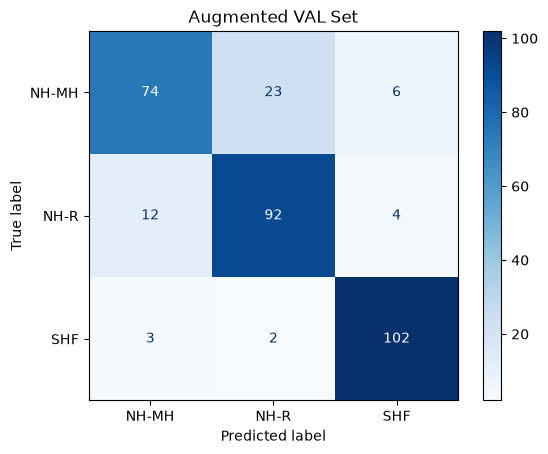

Augmented VAL Accuracy: 84.28%


In [15]:
abbrev_labels = {
    "Needle Holder Mayo-Hegar Straight Carb-bite Serrated Jaws 8in": "NH-MH",
    "Needle Holder Ryder Straight Carb-bite Serrated Jaws 8in": "NH-R",
    "Sponge Holding Forceps Foerster Straight Serrated 9.5in": "SHF"
}

display_labels = [
    abbrev_labels[name]
    for name in label_map.keys()
]

# Evaluate on augmented VAL set
val_labels, val_preds = evaluate_model(valLoader, model, device)

cm_val = confusion_matrix(val_labels, val_preds)

disp = ConfusionMatrixDisplay(cm_val, display_labels=display_labels)
disp.plot(cmap="Blues")
plt.title("Augmented VAL Set")
plt.show()

val_acc = np.mean(np.array(val_labels) == np.array(val_preds))
print(f"Augmented VAL Accuracy: {val_acc * 100:.2f}%")


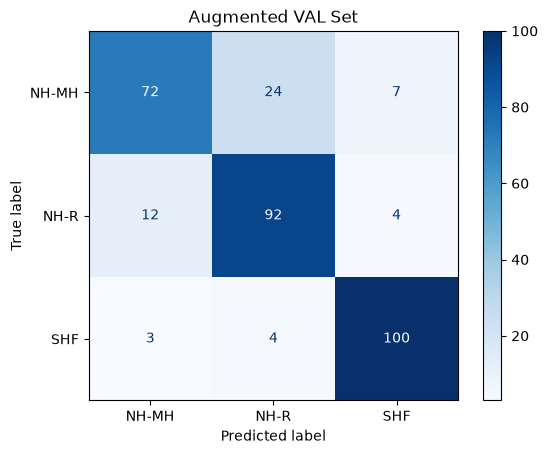

Augmented VAL Occluded Accuracy: 83.02%


In [17]:
# Evaluate on OCCLUDED augmented VAL set
val_labels, val_preds = evaluate_model(valLoaderOccluded, model, device)

cm_val = confusion_matrix(val_labels, val_preds)

disp = ConfusionMatrixDisplay(cm_val, display_labels=display_labels)
disp.plot(cmap="Blues")
plt.title("Augmented VAL Set")
plt.show()

val_acc = np.mean(np.array(val_labels) == np.array(val_preds))
print(f"Augmented VAL Occluded Accuracy: {val_acc * 100:.2f}%")